In [1]:
import numpy as np
import pandas as pd

from scipy import stats
from scipy.spatial import distance as dist
from scipy.signal import find_peaks

import matplotlib.pyplot as plt

import format_chronic_stim
import stim_plots
import format_waveform_data
import wormhole_analysis as analysis

import scipy.io
import os

### Load the data for each stim polarity

In [2]:
''' set paths '''
# set parent directory
# root_dir = "Z:/Isabel/data/hpc_implants/" # locker
root_dir = "../data/antidromic_stim/" # local

# session params
bird_id = "LIM63"
session_id = "240610"
ephys_id = "LIM63_240610_131820"
stim_pols = ["neg150", "neg250"]
show_plots = False
only_good = True

# data dirs
# session_dir = f"{root_dir}{bird_id}/{bird_id}_{session_id}/{ephys_id}/" # locker
session_dir = f"{root_dir}{bird_id}/" # local
ks_dir = "kilosort4_hash_blanked/"
ephys_dir = f"{session_dir}raw_ephys_output/"

# set save folder
save_folder = f"../figures/antidromic_hpc_to_lhy/{bird_id}/SfN2024/"
if os.path.isdir(save_folder):
    print('save folder exists')
else:
    os.mkdir(save_folder)

save folder exists


In [3]:
''' basic params '''
sampling_rate = 30000
t_pre = 0.02 # seconds collected before stim starts
t_post = 0.03 # seconds collected after stim time

In [4]:
''' load and preprocess the data '''
all_stim_times = []
all_filt_data = []
for stim_pol in stim_pols:
    print(f"\nloading and processing data for polarity = {stim_pol}")
    raw_ephys = format_chronic_stim.load_stim(ephys_dir, stim_pol=stim_pol)
    sorted_ephys, ch_names = format_chronic_stim.sort_stim_by_channel(ephys_dir, raw_ephys)
    [n_channels, n_samples, n_stim] = sorted_ephys.shape

    # get the stim times
    stim_times = np.load(f'{ephys_dir}stim_t_{stim_pol}.npy')
    stim_times = np.squeeze(stim_times.astype(int))
    assert(stim_times.shape[0]==n_stim)
    
    # get the channel info and crop as-needed
    broken_channels = np.asarray([14, 22, 48])
    start_idx = 0
    end_idx = n_stim
    ephys_data, ch_names = format_chronic_stim.trim_stim_data(sorted_ephys, ch_names,
                                                              broken_ch=broken_channels,
                                                              start_idx=start_idx, end_idx=end_idx)
    # data params
    [n_channels, n_samples, n_stim] = ephys_data.shape
    stim_times = stim_times[start_idx:end_idx]
    assert(stim_times.shape[0]==n_stim)
    print(f"n channels = {n_channels}, samples = {n_samples}, stim events = {n_stim}")
    
    # filter the data
    filt_data = format_chronic_stim.filter_stim_for_spikes(ephys_data)
    
    # save for each polarity
    all_stim_times.append(stim_times)
    all_filt_data.append(filt_data)


loading and processing data for polarity = neg150
loaded 665 stim events in 1.1562773000914603 seconds
../data/antidromic_stim/LIM63/raw_ephys_output/intan_info.mat
n channels = 61, samples = 1500, stim events = 665

loading and processing data for polarity = neg250
loaded 630 stim events in 1.4584882000926882 seconds
../data/antidromic_stim/LIM63/raw_ephys_output/intan_info.mat
n channels = 61, samples = 1500, stim events = 630


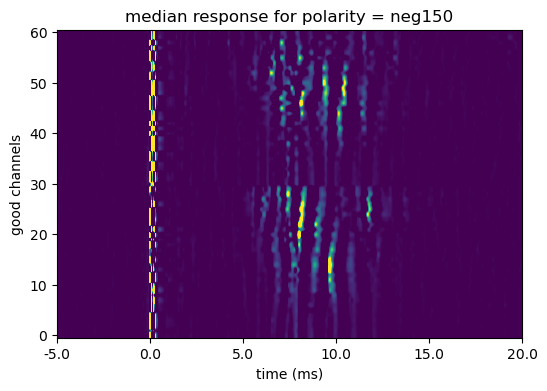

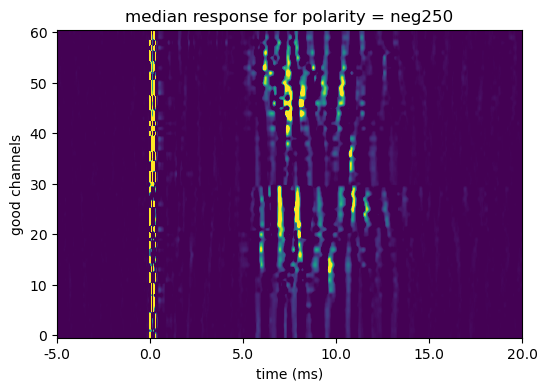

In [5]:
''' plot the median filtered hash for each polarity '''
for i, stim_pol in enumerate(stim_pols):
    f, ax = stim_plots.plot_avg_stim(all_filt_data[i], v_max=50)
    ax.set_title(f'median response for polarity = {stim_pol}')
    plt.show()

In [7]:
# reorder the axes for convenience
all_stim_hash = []
for filt_data in all_filt_data:
    all_stim_hash.append(np.moveaxis(filt_data, -1, 0))

In [8]:
all_stim_hash[0].shape

(665, 61, 1500)

In [9]:
''' get the channel info for each shank '''
A_shank = []
B_shank = []
for i, ch in enumerate(ch_names):
    if 'A' in ch:
        A_shank.append(i)
    else:
        B_shank.append(i)
A_shank = np.asarray(A_shank)
B_shank = np.asarray(B_shank)

In [10]:
''' load and format the waveform struct '''
waveform_struct = format_waveform_data.load_wf_data(session_dir, ks_dir=ks_dir)
wf_ids = waveform_struct['goodIDs']
mean_waveforms, wf_channels, _ = format_waveform_data.sort_wf_by_channel('', waveform_struct,
                                                                                 data_dir=ephys_dir)
# filter out the bad channels and get the new channel index
all_ch = np.arange(mean_waveforms.shape[1])
good_idx = np.setdiff1d(all_ch, broken_channels)
mean_waveforms = mean_waveforms[:, good_idx]
wf_ch_idx = np.asarray([ch_names.index(ch) for ch in wf_channels])
n_cells = mean_waveforms.shape[0]

# get the cell IDs and raw spike times
good_clusters, spike_id, spike_t = format_waveform_data.get_spike_times(session_dir, ks_dir=ks_dir)
assert good_clusters.shape[0] == n_cells

# get the relative spike times for each stim period
all_pre_stim_lat = []
for i, stim_times in enumerate(all_stim_times): 
    pre_stim_spikes = analysis.get_pre_stim_spikes(stim_times, spike_id, spike_t, sampling_rate=sampling_rate)
    all_pre_stim_lat.append(pre_stim_spikes)

../data/antidromic_stim/LIM63/kilosort4_hash_blanked/waveformStruct.mat
dict_keys(['mxWF', 'max_site', 'pcWF', 'meanRate', 'waveFormsMean', 'spkDur', 'spkOffset', 'goodIDs', 'goodLabels', 'medISI', 'contam', 'nSpikes'])
../data/antidromic_stim/LIM63/raw_ephys_output/intan_info.mat


### Load and format the data for collision-verified projection neurons

In [13]:
''' load and format the collision data '''
collision_dir = session_dir
all_collision_props = {}
for stim_pol in stim_pols:
    all_collision_props[stim_pol] = np.load(f'{collision_dir}collision_props_{stim_pol}.npy',
                                            allow_pickle=True).item()
    
shuff_150 = np.load(f'{collision_dir}shuff_100_neg150.npy')
shuff_250 = np.load(f'{collision_dir}shuff_100_neg250.npy')
all_shuffs = [shuff_150, shuff_250]

In [15]:
all_collision_props[stim_pols[0]].keys()

dict_keys(['trial_idx', 'n_short', 'masked_hash', 'LR_stat', 'change_idx', 'est_lat_ms', 'sig_cell_IDs', 'sig_cell_idx'])

In [26]:
''' organize into one big dict with only significant cell data '''
# remove double counted cells
collision_props_150 = all_collision_props[stim_pols[0]]
sig_cells_150 = collision_props_150['sig_cell_IDs']
collision_props_250 = all_collision_props[stim_pols[1]]
sig_cells_250 = collision_props_250['sig_cell_IDs']
all_sig_cells, unique_idx = np.unique(np.append(sig_cells_150, sig_cells_250), return_index=True)
n_sig_cells = all_sig_cells.shape[0]

# put everything in one dict
collision_props = {}
for key in all_collision_props[stim_pols[0]].keys():
    prop_150 = all_collision_props[stim_pols[0]][key]
    prop_250 = all_collision_props[stim_pols[1]][key]
    if len(prop_150.shape) == 1:
        collision_props[key] = np.append(prop_150, prop_250)[unique_idx]
    else:
        collision_props[key] = np.row_stack((prop_150, prop_250))[unique_idx]

# save the stim intensity/polarity index
polarities = np.ones(all_sig_cells.shape[0])
for i, cell in enumerate(all_sig_cells):
    if cell in sig_cells_150:
        polarities[i] = 0
collision_props["polarity_idx"] = polarities.astype(int)

In [29]:
''' add the kilosort info '''
sig_cell_idx = collision_props["sig_cell_idx"]
collision_props['pre_stim_lat'] = []
for c_idx in range(n_cells):    
    if c_idx in sig_cell_idx:
        pol_idx = int(collision_props["polarity_idx"][sig_cell_idx==c_idx])
        collision_props['pre_stim_lat'].append(all_pre_stim_lat[pol_idx][c_idx])

collision_props['wf_ch_idx'] = wf_ch_idx[sig_cell_idx].copy()

In [263]:
''' get the sorted trial index and best collision index, given the estimated collision latency '''
# data params
sig_cell_ids = collision_props['sig_cell_IDs']
sig_cell_idx = collision_props['sig_cell_idx']
est_lat_ms = collision_props['est_lat_ms']
pre_stim_spikes = collision_props['pre_stim_lat']

sorted_trial_idx = []
best_col_idx = np.full(n_sig_cells, np.NaN)
for i, (cell, c_idx) in enumerate(zip(sig_cell_ids, sig_cell_idx)):
    # sort the trials by latency to stim
    pre_stim_lat = pre_stim_spikes[i]
    lat_sort_idx = np.argsort(pre_stim_lat)
    sorted_trial_idx.append(lat_sort_idx.astype(int))

    # get the adjusted collision trial index
    lat_ms = est_lat_ms[i]
    sorted_latencies = pre_stim_lat[lat_sort_idx]
    lat_cell_ms = sorted_latencies/sampling_rate*1000
    if cell == 224: # 2 longest lat collision trials with the same latency
        best_col_idx[i] = np.argmin(np.abs(lat_cell_ms - lat_ms)) + 1
    else:
        best_col_idx[i] = np.argmin(np.abs(lat_cell_ms - lat_ms))

assert np.sum(np.isnan(best_col_idx)) == 0
collision_props["sorted_trial_idx"] = sorted_trial_idx
collision_props["best_col_idx"] = best_col_idx.astype(int)

In [264]:
''' adjust for slight differences between the collision and response latency/channel '''
collision_props['resp_lat_ms'] = np.asarray([10.8, 10.8, 9.7, 10.2, 7.4, 8, 7.5, 9.4, 10.4, 10.3, 7.55, 11.7])
collision_props['adj_ch_idx'] = np.asarray([0, -3, 1, -1, 0, 1, -4, 1, -1, 1, 2, 0])

<function matplotlib.pyplot.show(close=None, block=None)>

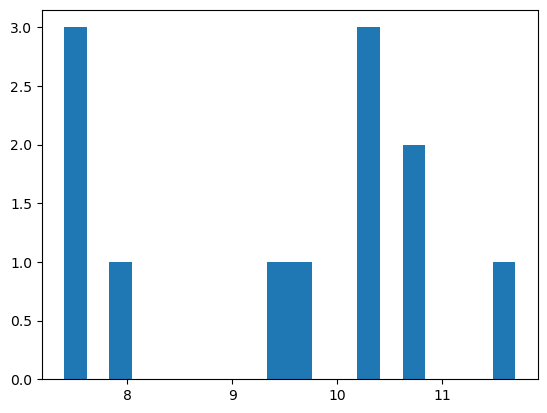

In [266]:
plt.hist(collision_props['resp_lat_ms'], bins=20)
plt.show

In [267]:
for key in collision_props.keys():
    try:
        print(f'{key}, ndarray of shape {collision_props[key].shape}')
    except:
        print(f'{key}, list of len {len(collision_props[key])}')

trial_idx, ndarray of shape (12, 120)
n_short, ndarray of shape (12,)
masked_hash, ndarray of shape (12, 120, 9, 360)
LR_stat, ndarray of shape (12, 119)
change_idx, ndarray of shape (12,)
est_lat_ms, ndarray of shape (12,)
sig_cell_IDs, ndarray of shape (12,)
sig_cell_idx, ndarray of shape (12,)
polarity_idx, ndarray of shape (12,)
pre_stim_lat, list of len 12
wf_ch_idx, ndarray of shape (12,)
sorted_trial_idx, list of len 12
best_col_idx, ndarray of shape (12,)
resp_lat_ms, ndarray of shape (12,)
adj_ch_idx, ndarray of shape (12,)


### Plot some things

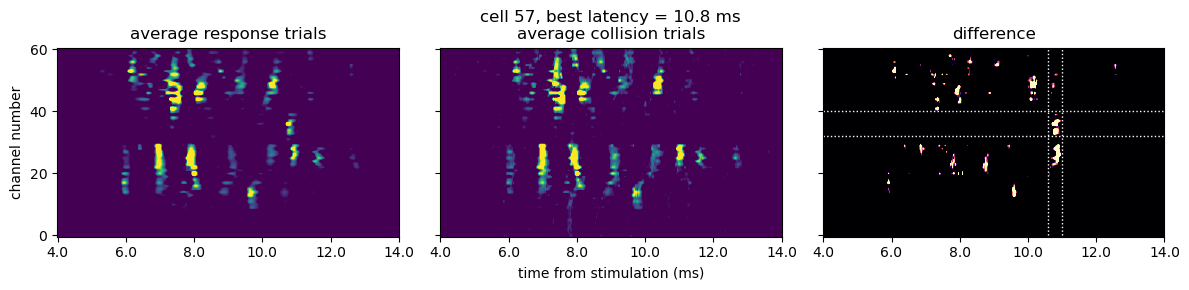

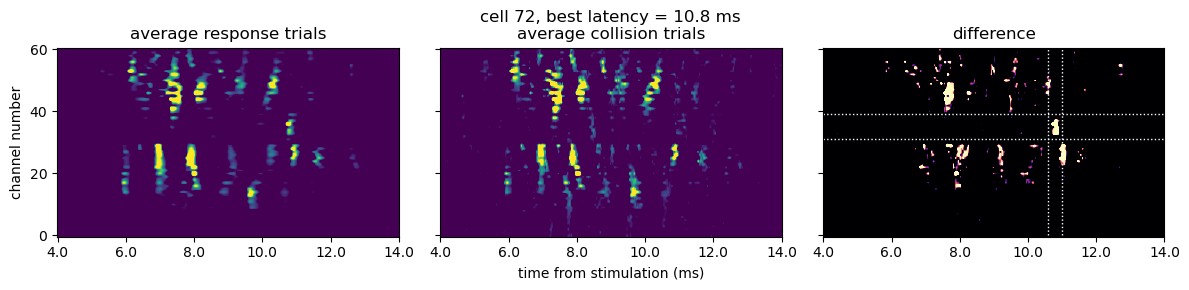

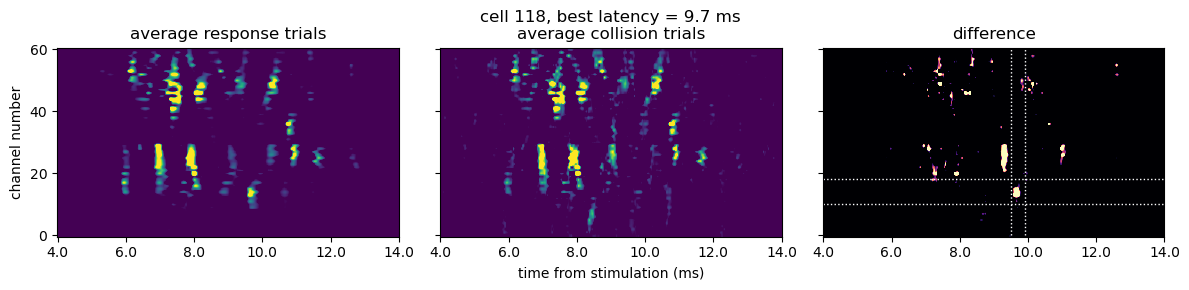

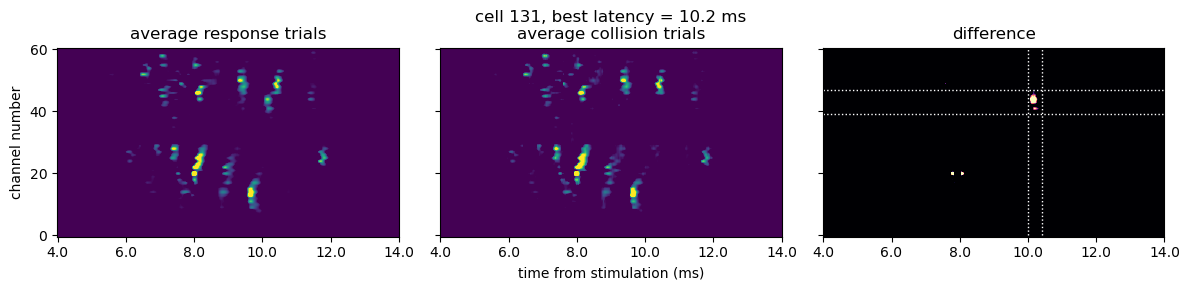

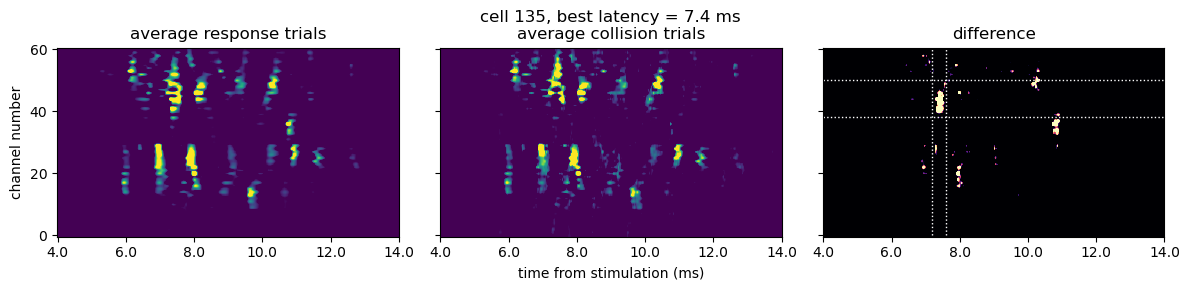

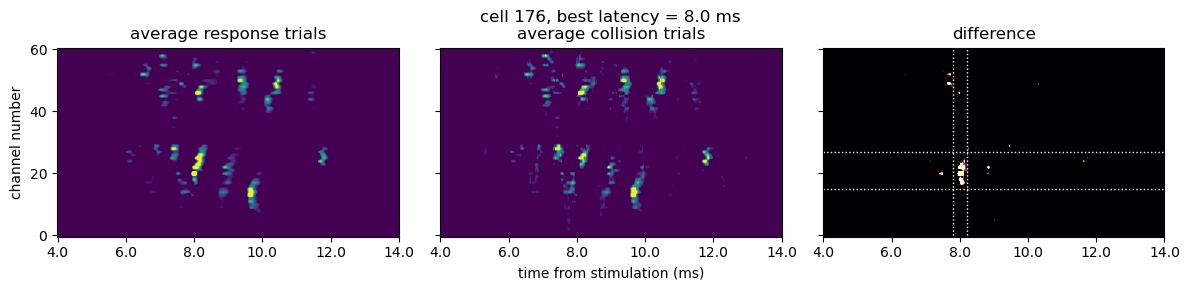

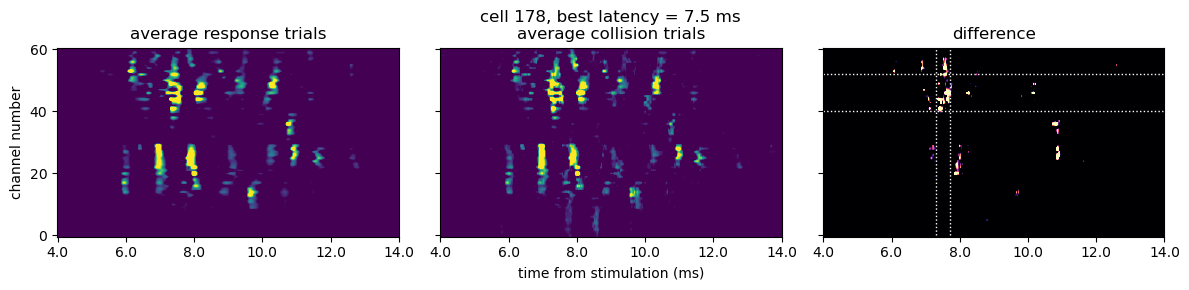

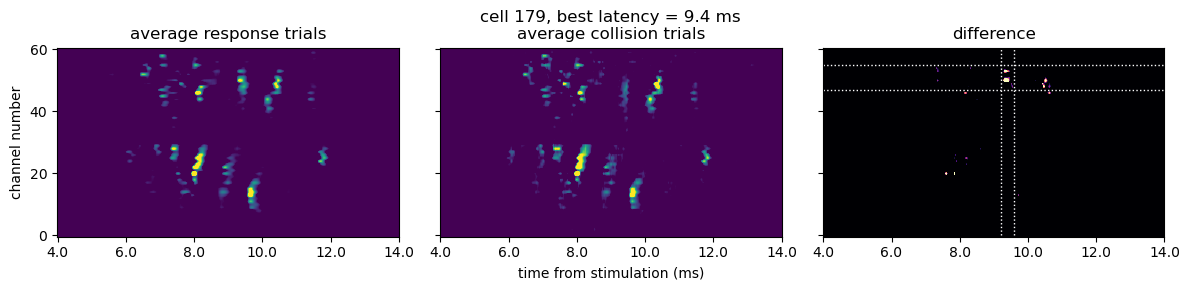

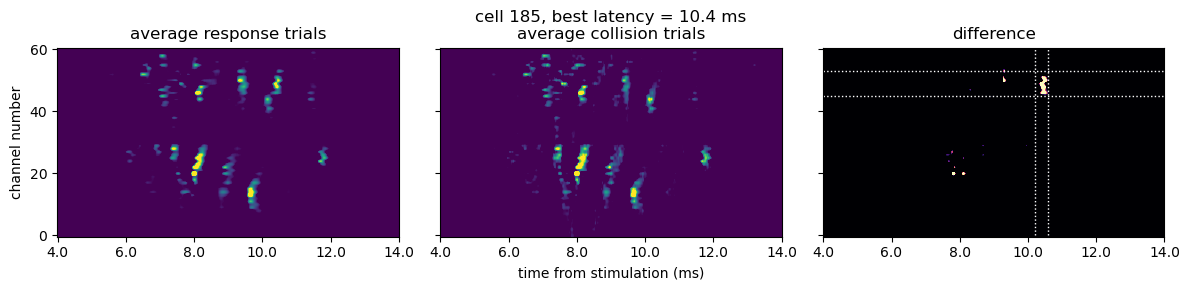

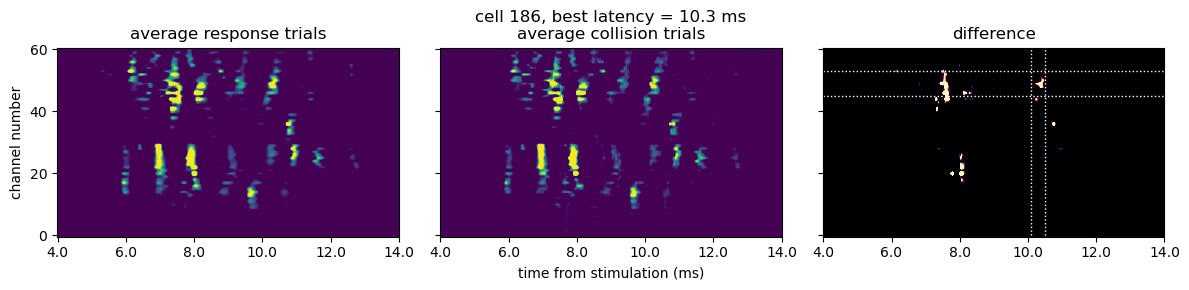

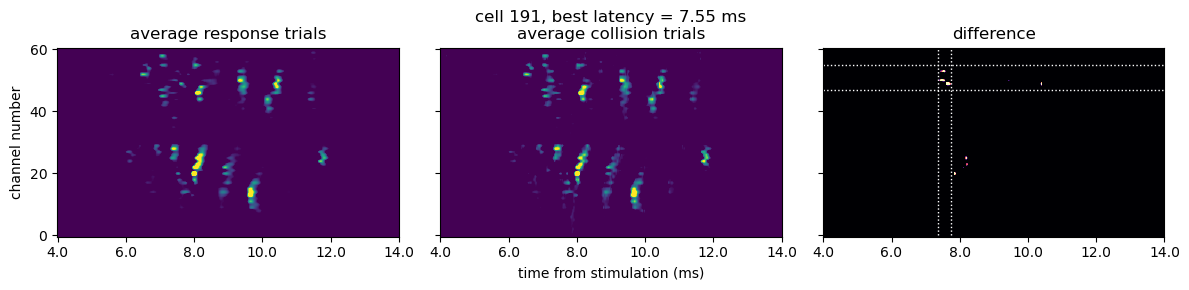

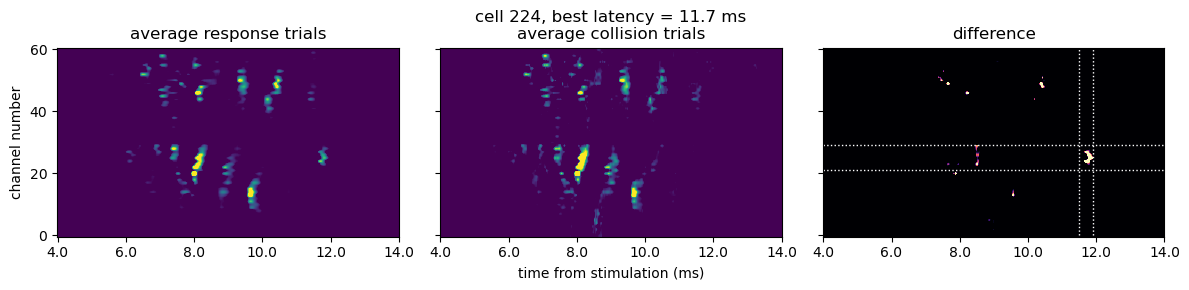

In [255]:
''' difference in pre- vs. post-collision hash for all significant cells '''
# plotting params
start_t = 4e-3
end_t = 14e-3
v_min = 10
v_max = 60
v_thresh = 20

# data params
sig_cell_idx = collision_props['sig_cell_idx']
sig_cell_ids = collision_props['sig_cell_IDs']

# set the time window to look at
start_t_adj = start_t + t_pre
end_t_adj = end_t + t_pre
start_idx = np.round(start_t_adj*sampling_rate).astype(int)
end_idx = np.round(end_t_adj*sampling_rate).astype(int)
n_bins = end_idx - start_idx

for j, (c_idx, cell) in enumerate(zip(sig_cell_idx, sig_cell_ids)):
    # get the relevant hash
    pol_id = collision_props['polarity_idx'][j]
    stim_hash = all_stim_hash[pol_id]
    stim_events = stim_hash[:, :, start_idx:end_idx]
    
    # get the collision trials
    sorted_trial_idx = collision_props["sorted_trial_idx"][j]
    best_col_idx = collision_props["best_col_idx"][j] + 1
    
    # take the median collision vs. non-collision
    sorted_hash = stim_events[sorted_trial_idx]
    collision_hash = np.median(sorted_hash[:best_col_idx], axis=0)
    response_hash = np.median(sorted_hash[best_col_idx:], axis=0)
    hash_diff = response_hash - collision_hash
    
    # plot the hashes and difference
    fig, ax = plt.subplots(1, 3, figsize=(12, 3))
    ax[0].imshow(-response_hash, clim=[v_min, v_max],
                     aspect='auto', cmap='viridis')
    ax[0].set_title(f'average response trials')
    ax[1].imshow(-collision_hash, clim=[v_min, v_max],
                 aspect='auto', cmap='viridis')
    ax[2].imshow(-hash_diff, clim=[20, 30],
                 aspect='auto', cmap='magma')
    ax[2].set_title(f'difference')
    
    # plot the rough stim response time
    lat_ms = collision_props['resp_lat_ms'][j]
    lat_samp = (lat_ms/1000 - start_t)*sampling_rate
    ax[2].vlines(lat_samp-6, 0, n_channels-1, 
              colors='w', 
              linestyles='dotted', lw=1)
    ax[2].vlines(lat_samp+6, 0, n_channels-1, 
              colors='w', 
              linestyles='dotted', lw=1)
    
    # plot the rough channel
    best_ch = wf_ch_idx[c_idx] + collision_props['adj_ch_idx'][j]
    if cell == 178:
        ch_buffer = 6
    elif (cell == 135) | (cell == 176):
        ch_buffer = 6
    else:
        ch_buffer = 4
    ax[2].hlines(best_ch-ch_buffer, 0, n_bins-1, 
              colors='w', 
              linestyles='dotted', lw=1)
    ax[2].hlines(best_ch+ch_buffer, 0, n_bins-1, 
              colors='w', 
              linestyles='dotted', lw=1)
    
    # save the pixel index of the antidromic response
    ch_start = int(best_ch-ch_buffer)
    ch_end = int(best_ch+ch_buffer)
    samp_start = int(lat_samp-6)
    samp_end = int(lat_samp+6)
    cropped_hash = hash_diff[ch_start:ch_end, samp_start:samp_end]

    # ticks and labels
    ax[1].set_title(f'cell {cell}, best latency = {lat_ms} ms\naverage collision trials')
    ax[0].set_ylabel('channel number')
    ax[1].tick_params(labelleft=False)
    ax[2].tick_params(labelleft=False)
    ax[1].set_xlabel('time from stimulation (ms)')
    for i in range(3):
        ax[i].set_ylim(ax[i].get_ylim()[::-1])
        ax[i].set_xticks(np.arange(0, n_bins+1, 0.002*sampling_rate))
        ax[i].set_xticklabels(np.arange(start_t*1000, end_t*1000+1, 2))
    plt.tight_layout()
    plt.show()
    
    fig.savefig(f'{save_folder}/hash_differences/{cell}_{stim_pol}.png', 
                      dpi=600, bbox_inches='tight')

In [83]:
''' get box params for all cells '''
# figure params
start_t=4e-3
end_t=14e-3
v_min=5
v_max=50
lat_buffer = 7

# data params
sig_cell_idx = collision_props['sig_cell_idx']
sig_cell_ids = collision_props['sig_cell_IDs']

# large or small channel range
ch_buffers = np.full(n_sig_cells, 4)
for i, cell in enumerate(sig_cell_ids):
    if cell in np.asarray([135, 176, 178]):
        ch_buffers[i] = 6

# doubling index
idx = np.arange(n_sig_cells)
dbl_idx = np.sort(np.append(idx, idx))
dbl_sig_idx = np.sort(np.append(sig_cell_idx, sig_cell_idx))

# latency ranges
lat_ms = collision_props['resp_lat_ms'].copy()
lat_samp = (lat_ms/1000 - start_t)*sampling_rate
lat_starts = lat_samp[dbl_idx] - lat_buffer
lat_ends = lat_samp[dbl_idx] + lat_buffer
lat_bounds = lat_starts.copy()
lat_bounds[1::2] = lat_ends[1::2]

# channel ranges
best_ch = wf_ch_idx[sig_cell_idx] + collision_props['adj_ch_idx'] - 1
ch_starts = best_ch[dbl_idx] - ch_buffer
ch_ends = best_ch[dbl_idx] + ch_buffer
ch_bounds = ch_starts.copy()
ch_bounds[1::2] = ch_ends[1::2]

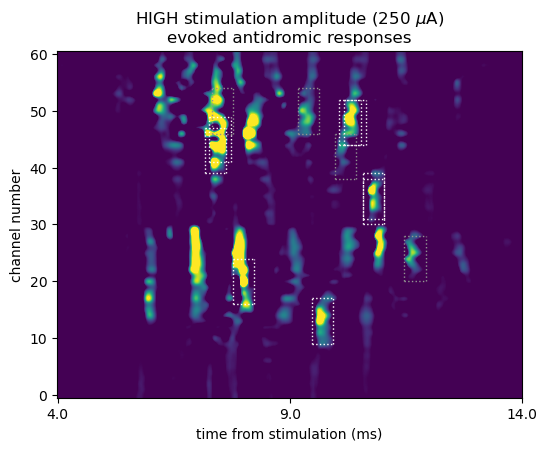

In [86]:
''' plot average hash (250uA) with all cells highlighted '''
# avg across stim events
avg_stim = np.median(all_stim_hash[1], axis=0)

# set the time window to look at
start_t_adj = start_t + t_pre
end_t_adj = end_t + t_pre
start_idx = np.round(start_t_adj*sampling_rate).astype(int)
end_idx = np.round(end_t_adj*sampling_rate).astype(int)

# grab that window
stim_events = avg_stim[:, start_idx:end_idx]
n_bins = stim_events.shape[1]

# plot the average hash
f, ax = plt.subplots(1, 1, figsize=(6, 4.5))
ax.imshow(-stim_events, clim=[v_min, v_max],
          aspect='auto', cmap='viridis',
          interpolation='gaussian')

# highlight example cell responses
for j, (c_idx, cell) in enumerate(zip(sig_cell_idx, sig_cell_ids)):
    i = dbl_sig_idx==c_idx
    if cell in sig_cells_250:
        ax.vlines(lat_bounds[i], ch_starts[i], ch_ends[i], 
                     colors='white', linestyles='dotted', lw=1)
        ax.hlines(ch_bounds[i], lat_starts[i], lat_ends[i], 
                     colors='white', linestyles='dotted', lw=1)
    else:
        ax.vlines(lat_bounds[i], ch_starts[i], ch_ends[i], 
                     colors='xkcd:grey', linestyles='dotted', lw=1)
        ax.hlines(ch_bounds[i], lat_starts[i], lat_ends[i], 
                     colors='xkcd:grey', linestyles='dotted', lw=1)

# axes and labels
ax.set_ylim(ax.get_ylim()[::-1])
ax.set_xticks(np.arange(0, n_bins+1, 0.005*sampling_rate))
ax.set_xticklabels(np.arange(start_t*1000, end_t*1000+2, 5))
ax.set_xlabel('time from stimulation (ms)')
ax.set_ylabel('channel number')
ax.set_title('HIGH stimulation amplitude (250 $\mu$A)\nevoked antidromic responses')

plt.show()
f.savefig(f'{save_folder}/median_hash_all_cells_neg250.png', 
                      dpi=600, bbox_inches='tight')

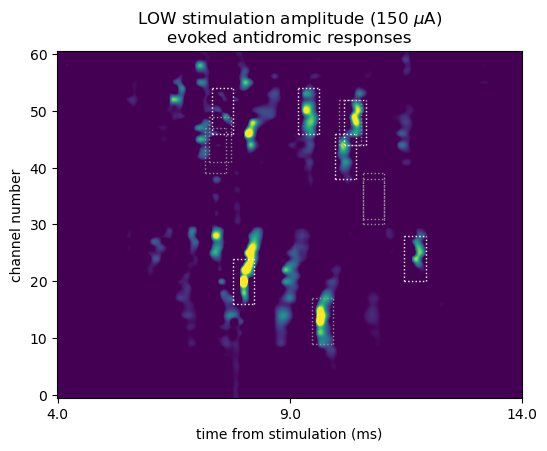

In [87]:
''' plot average hash (150uA) with all cells highlighted '''
# avg across stim events
avg_stim = np.median(all_stim_hash[0], axis=0)

# set the time window to look at
start_t_adj = start_t + t_pre
end_t_adj = end_t + t_pre
start_idx = np.round(start_t_adj*sampling_rate).astype(int)
end_idx = np.round(end_t_adj*sampling_rate).astype(int)

# grab that window
stim_events = avg_stim[:, start_idx:end_idx]
n_bins = stim_events.shape[1]

# plot the average hash
f, ax = plt.subplots(1, 1, figsize=(6, 4.5))
ax.imshow(-stim_events, clim=[v_min, v_max],
          aspect='auto', cmap='viridis',
          interpolation='gaussian')

# highlight example cell responses
for j, (c_idx, cell) in enumerate(zip(sig_cell_idx, sig_cell_ids)):
    i = dbl_sig_idx==c_idx
    if cell in sig_cells_150:
        ax.vlines(lat_bounds[i], ch_starts[i], ch_ends[i], 
                     colors='white', linestyles='dotted', lw=1)
        ax.hlines(ch_bounds[i], lat_starts[i], lat_ends[i], 
                     colors='white', linestyles='dotted', lw=1)
    else:
        ax.vlines(lat_bounds[i], ch_starts[i], ch_ends[i], 
                     colors='xkcd:grey', linestyles='dotted', lw=1)
        ax.hlines(ch_bounds[i], lat_starts[i], lat_ends[i], 
                     colors='xkcd:grey', linestyles='dotted', lw=1)

# axes and labels
ax.set_ylim(ax.get_ylim()[::-1])
ax.set_xticks(np.arange(0, n_bins+1, 0.005*sampling_rate))
ax.set_xticklabels(np.arange(start_t*1000, end_t*1000+2, 5))
ax.set_xlabel('time from stimulation (ms)')
ax.set_ylabel('channel number')
ax.set_title('LOW stimulation amplitude (150 $\mu$A)\nevoked antidromic responses')

plt.show()
f.savefig(f'{save_folder}/median_hash_all_cells_neg150.png', 
                      dpi=600, bbox_inches='tight')

In [90]:
''' longer time window (include stim time) '''
''' get box params for all cells '''
# figure params
start_t=-2e-3
end_t=14e-3
v_min=5
v_max=50
lat_buffer = 7

# data params
sig_cell_idx = collision_props['sig_cell_idx']
sig_cell_ids = collision_props['sig_cell_IDs']

# large or small channel range
ch_buffers = np.full(n_sig_cells, 4)
for i, cell in enumerate(sig_cell_ids):
    if cell in np.asarray([135, 176, 178]):
        ch_buffers[i] = 6

# doubling index
idx = np.arange(n_sig_cells)
dbl_idx = np.sort(np.append(idx, idx))
dbl_sig_idx = np.sort(np.append(sig_cell_idx, sig_cell_idx))

# latency ranges
lat_ms = collision_props['resp_lat_ms'].copy()
lat_samp = (lat_ms/1000 - start_t)*sampling_rate
lat_starts = lat_samp[dbl_idx] - lat_buffer
lat_ends = lat_samp[dbl_idx] + lat_buffer
lat_bounds = lat_starts.copy()
lat_bounds[1::2] = lat_ends[1::2]

# channel ranges
best_ch = wf_ch_idx[sig_cell_idx] + collision_props['adj_ch_idx'] - 1
ch_starts = best_ch[dbl_idx] - ch_buffer
ch_ends = best_ch[dbl_idx] + ch_buffer
ch_bounds = ch_starts.copy()
ch_bounds[1::2] = ch_ends[1::2]

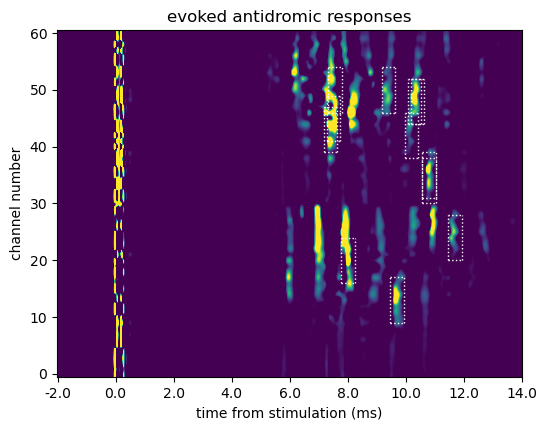

In [96]:
''' plot average hash (250uA) with all cells highlighted '''
# avg across stim events
avg_stim = np.median(all_stim_hash[1], axis=0)

# set the time window to look at
start_t_adj = start_t + t_pre
end_t_adj = end_t + t_pre
start_idx = np.round(start_t_adj*sampling_rate).astype(int)
end_idx = np.round(end_t_adj*sampling_rate).astype(int)

# grab that window
stim_events = avg_stim[:, start_idx:end_idx]
n_bins = stim_events.shape[1]

# plot the average hash
f, ax = plt.subplots(1, 1, figsize=(6, 4.5))
ax.imshow(-stim_events, clim=[v_min, v_max],
          aspect='auto', cmap='viridis',
          interpolation='gaussian')

# highlight example cell responses
ax.vlines(lat_bounds, ch_starts, ch_ends, 
             colors='white', linestyles='dotted', lw=1)
ax.hlines(ch_bounds, lat_starts, lat_ends, 
             colors='white', linestyles='dotted', lw=1)

# axes and labels
ax.set_ylim(ax.get_ylim()[::-1])
ax.set_xticks(np.arange(0, n_bins+1, 0.002*sampling_rate))
ax.set_xticklabels(np.arange(start_t*1000, end_t*1000+2, 2))
ax.set_xlabel('time from stimulation (ms)')
ax.set_ylabel('channel number')
ax.set_title('evoked antidromic responses')

plt.show()
f.savefig(f'{save_folder}/median_hash_stim_inc.png', 
                      dpi=600, bbox_inches='tight')

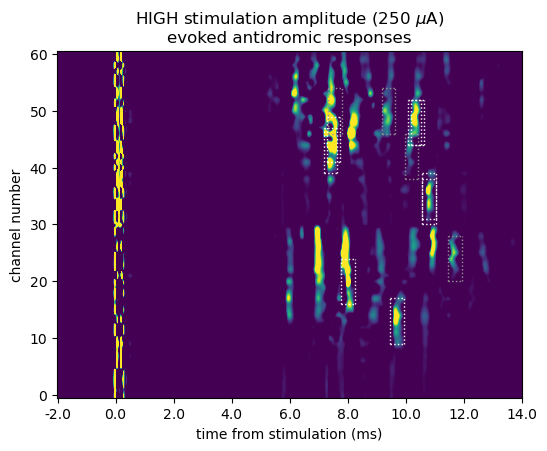

In [92]:
''' plot average hash (250uA) with all cells highlighted '''
# avg across stim events
avg_stim = np.median(all_stim_hash[1], axis=0)

# set the time window to look at
start_t_adj = start_t + t_pre
end_t_adj = end_t + t_pre
start_idx = np.round(start_t_adj*sampling_rate).astype(int)
end_idx = np.round(end_t_adj*sampling_rate).astype(int)

# grab that window
stim_events = avg_stim[:, start_idx:end_idx]
n_bins = stim_events.shape[1]

# plot the average hash
f, ax = plt.subplots(1, 1, figsize=(6, 4.5))
ax.imshow(-stim_events, clim=[v_min, v_max],
          aspect='auto', cmap='viridis',
          interpolation='gaussian')

# highlight example cell responses
for j, (c_idx, cell) in enumerate(zip(sig_cell_idx, sig_cell_ids)):
    i = dbl_sig_idx==c_idx
    if cell in sig_cells_250:
        ax.vlines(lat_bounds[i], ch_starts[i], ch_ends[i], 
                     colors='white', linestyles='dotted', lw=1)
        ax.hlines(ch_bounds[i], lat_starts[i], lat_ends[i], 
                     colors='white', linestyles='dotted', lw=1)
    else:
        ax.vlines(lat_bounds[i], ch_starts[i], ch_ends[i], 
                     colors='xkcd:grey', linestyles='dotted', lw=1)
        ax.hlines(ch_bounds[i], lat_starts[i], lat_ends[i], 
                     colors='xkcd:grey', linestyles='dotted', lw=1)

# axes and labels
ax.set_ylim(ax.get_ylim()[::-1])
ax.set_xticks(np.arange(0, n_bins+1, 0.002*sampling_rate))
ax.set_xticklabels(np.arange(start_t*1000, end_t*1000+2, 2))
ax.set_xlabel('time from stimulation (ms)')
ax.set_ylabel('channel number')
ax.set_title('HIGH stimulation amplitude (250 $\mu$A)\nevoked antidromic responses')

plt.show()
f.savefig(f'{save_folder}/median_hash_stim_inc_250.png', 
                      dpi=600, bbox_inches='tight')

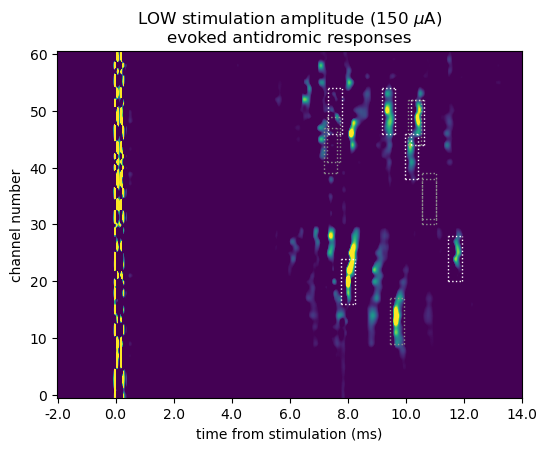

In [94]:
''' plot average hash (150uA) with all cells highlighted '''
# avg across stim events
avg_stim = np.median(all_stim_hash[0], axis=0)

# set the time window to look at
start_t_adj = start_t + t_pre
end_t_adj = end_t + t_pre
start_idx = np.round(start_t_adj*sampling_rate).astype(int)
end_idx = np.round(end_t_adj*sampling_rate).astype(int)

# grab that window
stim_events = avg_stim[:, start_idx:end_idx]
n_bins = stim_events.shape[1]

# plot the average hash
f, ax = plt.subplots(1, 1, figsize=(6, 4.5))
ax.imshow(-stim_events, clim=[v_min, v_max],
          aspect='auto', cmap='viridis',
          interpolation='gaussian')

# highlight example cell responses
for j, (c_idx, cell) in enumerate(zip(sig_cell_idx, sig_cell_ids)):
    i = dbl_sig_idx==c_idx
    if cell in sig_cells_150:
        ax.vlines(lat_bounds[i], ch_starts[i], ch_ends[i], 
                     colors='white', linestyles='dotted', lw=1)
        ax.hlines(ch_bounds[i], lat_starts[i], lat_ends[i], 
                     colors='white', linestyles='dotted', lw=1)
    else:
        ax.vlines(lat_bounds[i], ch_starts[i], ch_ends[i], 
                     colors='xkcd:grey', linestyles='dotted', lw=1)
        ax.hlines(ch_bounds[i], lat_starts[i], lat_ends[i], 
                     colors='xkcd:grey', linestyles='dotted', lw=1)

# axes and labels
ax.set_ylim(ax.get_ylim()[::-1])
ax.set_xticks(np.arange(0, n_bins+1, 0.002*sampling_rate))
ax.set_xticklabels(np.arange(start_t*1000, end_t*1000+2, 2))
ax.set_xlabel('time from stimulation (ms)')
ax.set_ylabel('channel number')
ax.set_title('LOW stimulation amplitude (150 $\mu$A)\nevoked antidromic responses')

plt.show()
f.savefig(f'{save_folder}/median_hash_stim_inc_neg150.png', 
                      dpi=600, bbox_inches='tight')

In [ ]:
'''
Notes/thoughts
--------------
Roughly 12 collision-verified projection units detected.
Looking through the heat maps, there are ~8 unidentified worms at 15uA and ~10 more at 250uA.
Reasons for undetected worms:
- not enough trials with spikes (required 120)
- not enough collision trials (required at least 1, but hard to detect if few + spontaneous spiking)
- these are polysynaptic or orthodromic responses (true negatives)
--> would expect these to be lower peaks in the average hash, and these missed worms are not counting faint worms

'''

### Make some nice plots for the example cells

In [256]:
example_cells = np.asarray([131, 135, 176,
                            179, 186, 191, 224])
n_example_cells = example_cells.shape[0]

In [257]:
ex_cell_idx = []
for c_idx, cell in zip(sig_cell_idx, sig_cell_ids):
    if cell in example_cells:
        ex_cell_idx.append(c_idx)
ex_cell_idx = np.asarray(ex_cell_idx).astype(int)
print(f'example cells {good_clusters[ex_cell_idx]}')

example cells [131 135 176 179 186 191 224]


In [532]:
''' get evenly spaced collision and response trial indices for each example cell '''
# plotting params
n_col_trials = 4
n_resp_trials = 4
n_total_trials = n_col_trials + n_resp_trials

# set the time window to look at - traces
start_t = -15e-3 # in seconds
end_t = 15e-3 # in seconds
start_t_adj = start_t + t_pre
end_t_adj = end_t + t_pre
start_idx = np.round(start_t_adj*sampling_rate).astype(int)
end_idx = np.round(end_t_adj*sampling_rate).astype(int)
start_ms = start_t*1000

ex_trial_idx_all = np.full((n_sig_cells, n_total_trials), np.NaN)
ex_latencies_all = np.full((n_sig_cells, n_total_trials), np.NaN)
ex_LR_idx = np.full((n_sig_cells, n_total_trials), np.NaN)
for sig_idx, (c_idx, cell) in enumerate(zip(sig_cell_idx, sig_cell_ids)):
    if cell in example_cells:
        # data params
        LR_cell = collision_props['LR_stat'][sig_idx]
        col_idx = collision_props["best_col_idx"][sig_idx]
        pre_stim_lat = collision_props['pre_stim_lat'][sig_idx]

        # all trial indices, clipped at pre-stim start time
        all_trial_idx = collision_props['trial_idx'][sig_idx]
        trial_latencies = pre_stim_lat[all_trial_idx]
        trial_idx = all_trial_idx[trial_latencies < -sampling_rate*start_t]
        if trial_idx[col_idx+1:].shape[0] < n_resp_trials:
            print(f"cell {cell} not enough long latency trials")
            n_example_cells = n_example_cells - 1
            continue
        elif trial_idx[:col_idx].shape[0] < n_col_trials:
            print(f"cell {cell} not enough collision trials")
            n_example_cells = n_example_cells - 1
            continue

        # collision trial index, sorted by latency
        col_latencies = pre_stim_lat[trial_idx[:col_idx+1]]
        spaced_lat = np.linspace(col_latencies[0], col_latencies[-1], n_col_trials)
        col_lat_idx = np.full(n_col_trials, np.NaN)
        for i, l in enumerate(spaced_lat):
            col_lat_idx[i] = np.argmin(np.abs(col_latencies-l))
            if col_lat_idx[i] == col_lat_idx[i-1]:
                col_lat_idx[i] = col_lat_idx[i] + 1
        col_trial_idx = trial_idx[col_lat_idx.astype(int)]
        subsamp_latencies = np.round(pre_stim_lat[col_trial_idx]/sampling_rate*1000, 2)

        # response trial index, sorted by latency
        n_total_resp = trial_idx[col_idx+1:].shape[0]
        spacer = step // np.round(col_idx / n_total_resp)
        min_r_idx = np.max((col_idx+int(spacer-1), col_idx+1))
        resp_latencies = pre_stim_lat[trial_idx[min_r_idx:]]
        spaced_lat = np.linspace(resp_latencies[0], resp_latencies[-1], n_resp_trials)
        resp_lat_idx = np.full(n_resp_trials, np.NaN)
        for i, l in enumerate(spaced_lat):
            resp_lat_idx[i] = np.argmin(np.abs(resp_latencies-l)) + min_r_idx
            if resp_lat_idx[i] == resp_lat_idx[i-1]:
                resp_lat_idx[i] = resp_lat_idx[i] + 1
        resp_trial_idx = trial_idx[resp_lat_idx.astype(int)]
        subsamp_latencies = np.append(subsamp_latencies,
                                      np.round(pre_stim_lat[resp_trial_idx]/sampling_rate*1000, 2))
        ex_trial_idx = np.append(col_trial_idx, resp_trial_idx)
        assert all(np.sort(ex_trial_idx) == np.intersect1d(all_trial_idx, ex_trial_idx))

        # get the trial index for the likelihood ratio
        LR_trial_idx = np.full(n_total_trials, np.NaN)
        j = 0
        for k, tr in enumerate(all_trial_idx):
            if tr in ex_trial_idx:
                LR_trial_idx[j] = k
                j += 1
        LR_trial_idx = LR_trial_idx.astype(int)
        ex_LR_idx[sig_idx] = LR_trial_idx

        # flip trial order so longer latencies come first
        ex_latencies_all[sig_idx] = subsamp_latencies[::-1]
        ex_trial_idx_all[sig_idx] = ex_trial_idx[::-1]

In [533]:
''' get box params for all cells '''
start_t_hash = 4e-3 # in seconds
end_t_hash = 14e-3 # in seconds
start_t_adj_hash = start_t_hash + t_pre
end_t_adj_hash = end_t_hash + t_pre
start_idx_hash = np.round(start_t_adj_hash*sampling_rate).astype(int)
end_idx_hash = np.round(end_t_adj_hash*sampling_rate).astype(int)

# figure params
lat_buffer = 7

# data params
sig_cell_idx = collision_props['sig_cell_idx']
sig_cell_ids = collision_props['sig_cell_IDs']

# large or small channel range
ch_buffers = np.full(n_sig_cells, 4)
for i, cell in enumerate(sig_cell_ids):
    if cell in np.asarray([135, 176, 178]):
        ch_buffers[i] = 6

# doubling index
idx = np.arange(n_sig_cells)
dbl_idx = np.sort(np.append(idx, idx))
dbl_sig_idx = np.sort(np.append(sig_cell_idx, sig_cell_idx))

# latency ranges
lat_ms = collision_props['resp_lat_ms'].copy()
lat_samp = (lat_ms/1000 - start_t_hash)*sampling_rate
lat_starts = lat_samp[dbl_idx] - lat_buffer
lat_ends = lat_samp[dbl_idx] + lat_buffer
lat_bounds = lat_starts.copy()
lat_bounds[1::2] = lat_ends[1::2]

# channel ranges
best_ch = wf_ch_idx[sig_cell_idx] + collision_props['adj_ch_idx'] - 1
ch_starts = best_ch[dbl_idx] - ch_buffer
ch_ends = best_ch[dbl_idx] + ch_buffer
ch_bounds = ch_starts.copy()
ch_bounds[1::2] = ch_ends[1::2]

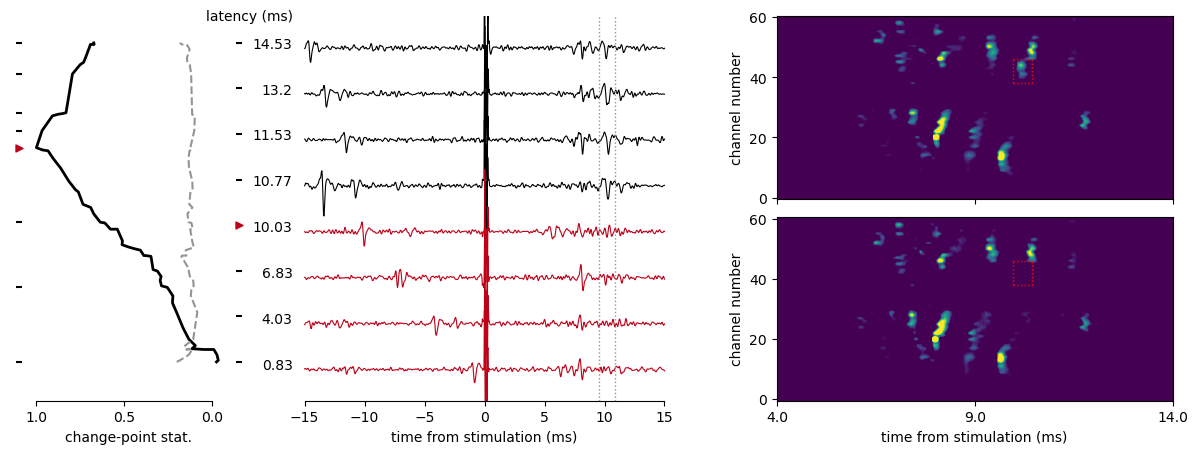

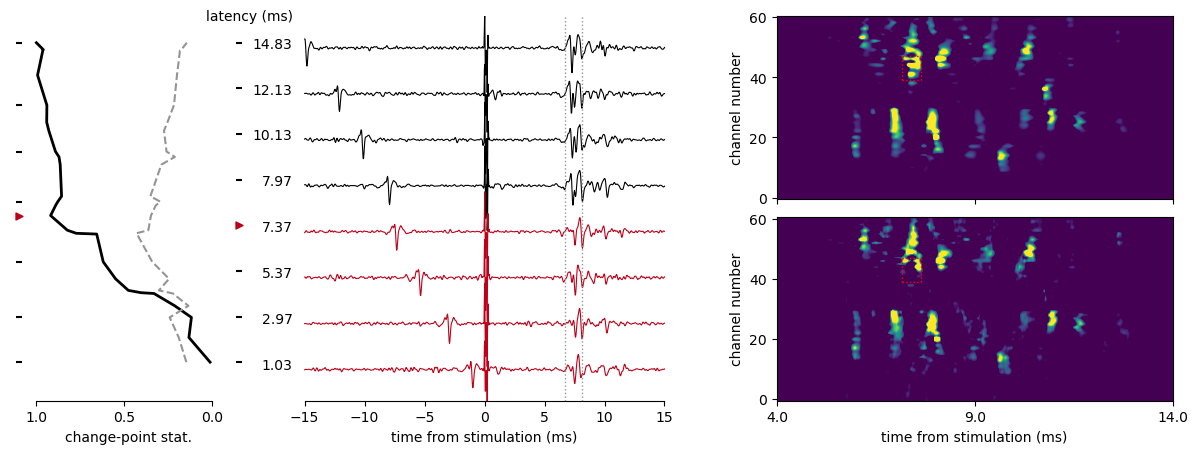

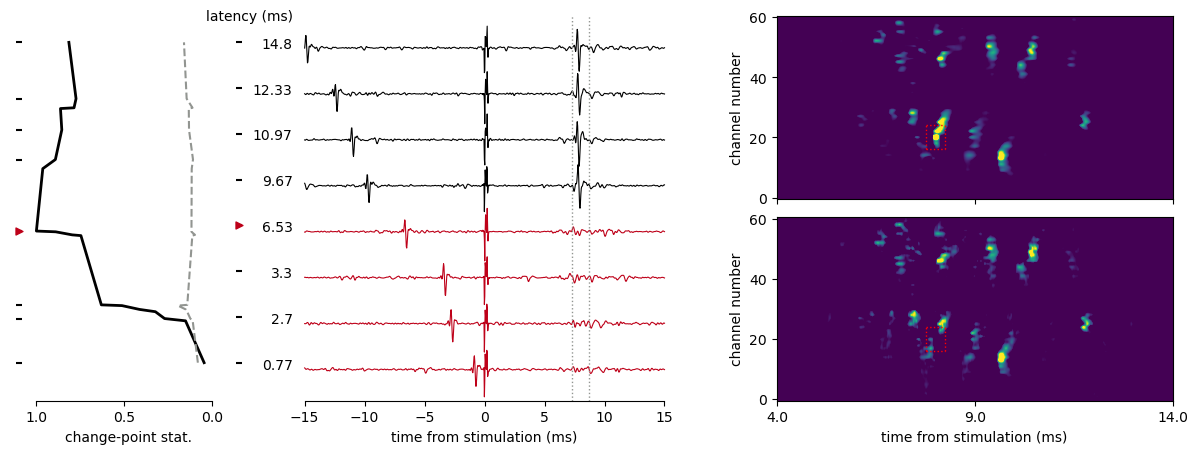

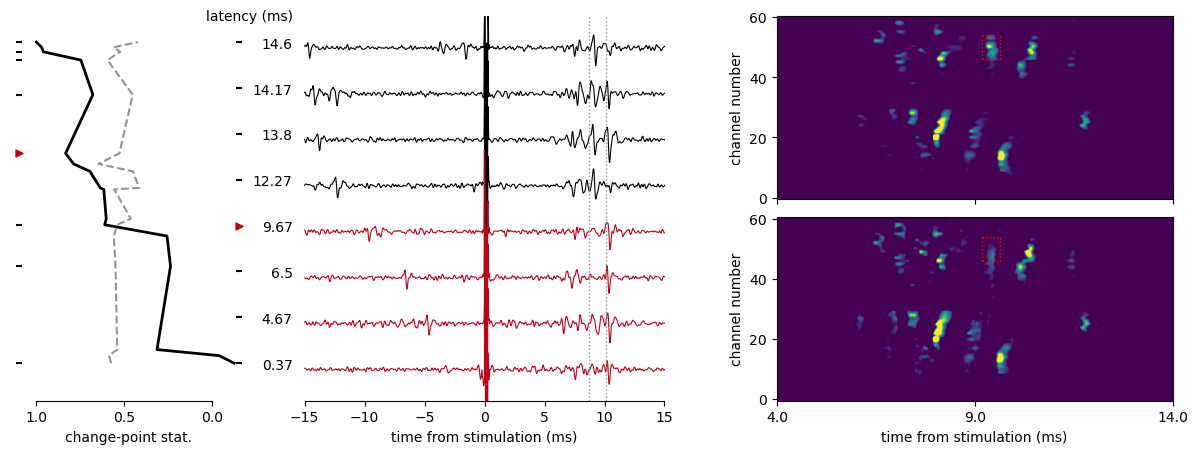

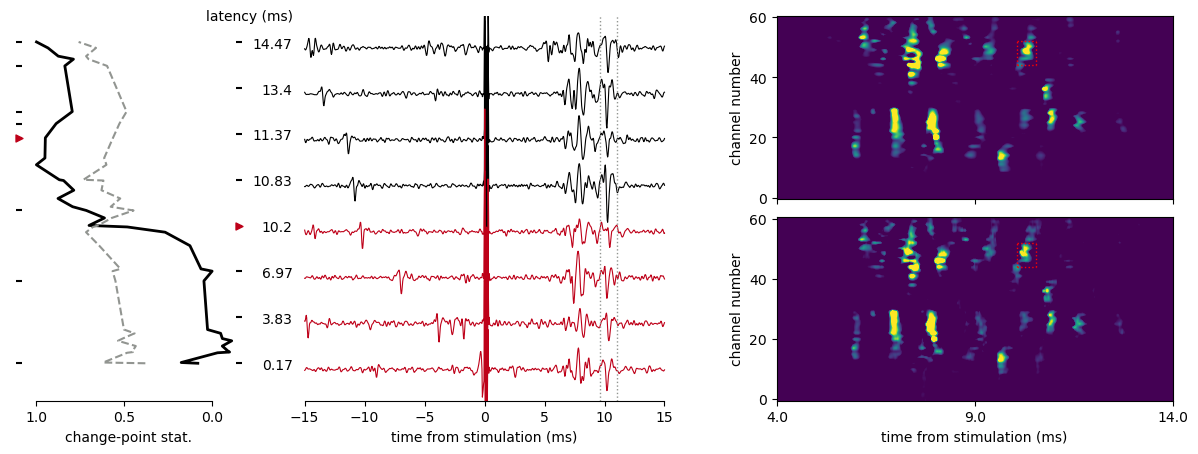

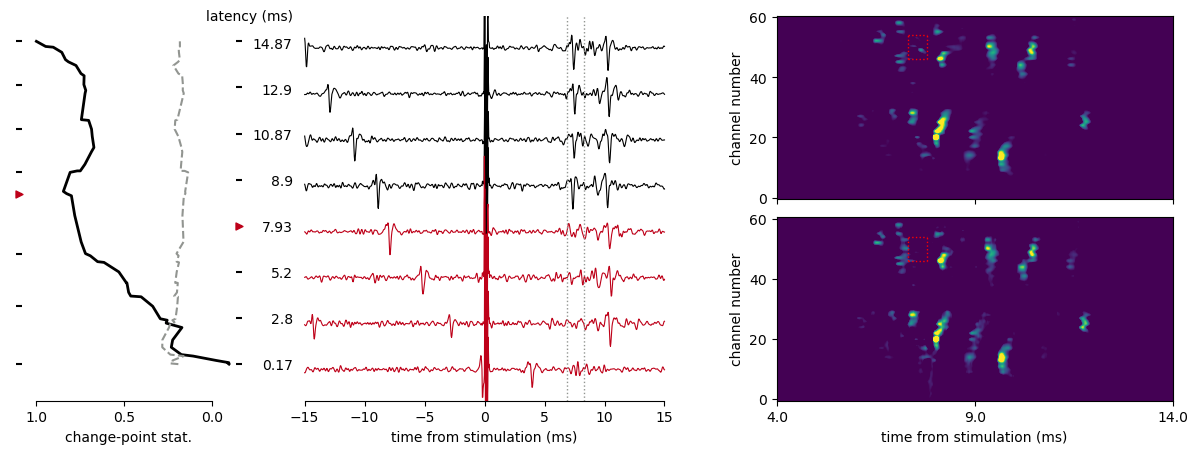

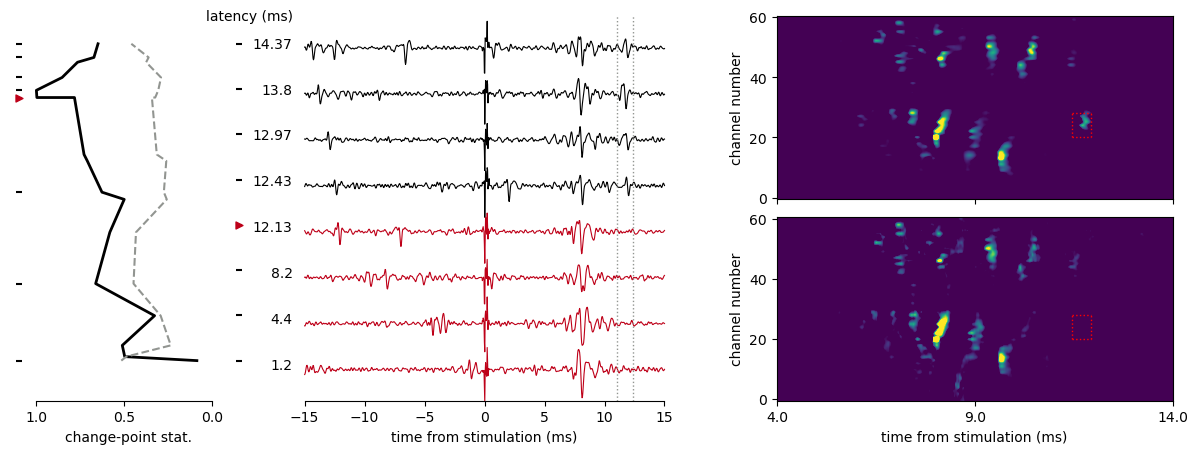

In [534]:
''' plot change point statistic and traces side-by-side '''
# plotting params
y_scales = np.full(n_example_cells, 300)
y_scales[[1, 3]] = np.asarray([500, 800])
x_range = np.arange(n_total_trials)
aligned_time = np.linspace(start_t*1000, end_t*1000, end_idx - start_idx)

for sig_idx, (c_idx, cell) in enumerate(zip(sig_cell_idx, sig_cell_ids)):
    if cell in example_cells:
        # data params
        pre_stim_lat = collision_props['pre_stim_lat'][sig_idx]
        LR_cell = collision_props['LR_stat'][sig_idx]
        col_idx = collision_props["best_col_idx"][sig_idx].astype(int)
        LR_trial_idx = ex_LR_idx[sig_idx].astype(int)
        ex_trial_idx = ex_trial_idx_all[sig_idx].astype(int)
        subsamp_latencies = ex_latencies_all[sig_idx]        
        pol_id = int(collision_props['polarity_idx'][sig_idx])

        # fig params
        gs_kw = dict(width_ratios=[15, 25, 1, 25], hspace=0.1, wspace=0.15)
        f, ax = plt.subplot_mosaic([[0, 1, 3, 20], [0, 1, 3, 21]],
                                   figsize=(15, 5), gridspec_kw=gs_kw)
        y_scale = y_scales[example_cells==cell]
        ax[3].spines['top'].set_visible(False)
        ax[3].spines['left'].set_visible(False)
        ax[3].spines['bottom'].set_visible(False)
        ax[3].spines['right'].set_visible(False)
        ax[3].set_xticks([])
        ax[3].set_yticks([])

        # PLOT ALL LR VS. SHUFFLE
        all_trial_idx = collision_props['trial_idx'][sig_idx]
        trial_latencies = pre_stim_lat[all_trial_idx]
        n_dist = LR_cell.shape[0]
        LR_latencies = trial_latencies[:-1][trial_latencies[:-1] < -sampling_rate*start_t]
        ex_LR = LR_cell[trial_latencies[:-1] < -sampling_rate*start_t]

        # get the shuffle and significant peaks
        shuff_LR = all_shuffs[pol_id]
        cell_shuff = shuff_LR[c_idx, :n_dist][trial_latencies[:-1] < -sampling_rate*start_t]
        shuff_99 = np.percentile(cell_shuff, 99, axis=1)
        LR_peaks_idx, _ = find_peaks(ex_LR)
        n_peaks = LR_peaks_idx.shape[0]
        sig_peaks = ex_LR[LR_peaks_idx] > shuff_99[LR_peaks_idx]

        # normalize s.t. 0 is mean of shuffle and 1 is max LR
        min_norm = np.mean(cell_shuff)
        max_norm = np.max(ex_LR - min_norm)
        norm_LR = (ex_LR - min_norm) / max_norm
        norm_shuff = (shuff_99 - min_norm) / max_norm

        # plot the data and shuffle
        ax[0].plot(norm_LR, LR_latencies, 'k', lw=2)
        ax[0].plot(norm_shuff, LR_latencies, 'xkcd:grey', ls='dashed')
        
        # mark the exmaple trials
        ex_lat_LR = np.intersect1d(LR_latencies, np.round(subsamp_latencies/1000*sampling_rate))
        yvals_LR = np.full(ex_lat_LR.shape[0], 1.1)
        ax[0].scatter(yvals_LR, ex_lat_LR, c='k', s=25, marker='_')
        ax[0].scatter(1.1, trial_latencies[col_idx], c='xkcd:scarlet', s=25, marker='>')
        ex_lat_traces = np.linspace(LR_latencies[0], LR_latencies[-1], n_total_trials)
        yvals_traces = np.full(ex_lat_LR.shape[0], -0.15)
        ax[0].scatter(yvals_traces, ex_lat_traces, c='k', s=25, marker='_')
        ax[0].scatter(-0.15, ex_lat_traces[n_col_trials-1], c='xkcd:scarlet', s=25, marker='>')

        # ticks and labels
        ax[0].set_yticks([])
        ax[0].yaxis.tick_right()
        ax[0].set_ylim(LR_latencies[0]-50, LR_latencies[-1]+35)
        ax[0].spines['right'].set_bounds(LR_latencies[0], LR_latencies[-1])
        ax[0].tick_params(labelright=False)

        ax[0].set_xticks([0, 0.5, 1])
        ax[0].set_xlim(1.15, -0.2)
        ax[0].spines['bottom'].set_bounds(1, 0)
        ax[0].set_xlabel('change-point stat.')

        ax[0].spines['top'].set_visible(False)
        ax[0].spines['left'].set_visible(False)
        ax[0].spines['right'].set_visible(False)

        # PLOT THE TRACES FROM EXAMPLE TRIALS
        # channel index
        best_ch = wf_ch_idx[c_idx]

        # grab the relevant ephys data
        med_sub_data = all_filt_data[pol_id]
        stim_events = med_sub_data[best_ch, start_idx:end_idx, ex_trial_idx]
        n_stim_events, n_bins = stim_events.shape

        # plot each trace shifted vertically from the others
        for i, s_event in enumerate(stim_events):
            if i >= n_resp_trials:
                ax[1].plot(aligned_time, s_event-i*y_scale, 'xkcd:scarlet', lw=0.8)
            else:
                ax[1].plot(aligned_time, s_event-i*y_scale, 'k', lw=0.8)    
            # label the latencies
            if i == 0:
                ax[1].text(start_ms-1, -i*y_scale + 0.6*y_scale, 
                        f'latency (ms)',
                        fontsize=10,
                        horizontalalignment='right')
            ax[1].text(start_ms-1, -i*y_scale, 
                    f'{subsamp_latencies[i]}',
                    fontsize=10,
                    horizontalalignment='right')

        # axis params
        ax[1].spines['bottom'].set_bounds(aligned_time[0], aligned_time[-1])
        ax[1].set_xlabel('time from stimulation (ms)')
        ax[1].set_ylim([(-n_stim_events)*(y_scale*0.96), y_scale*0.7])
        ylims = ax[1].get_ylim()
        # ax[1].set_title(f"cell {good_clusters[c_idx]} collisions")

        # plot the stim response time
        lat_ms = collision_props['resp_lat_ms'][sig_idx]
        ax[1].vlines(lat_ms-0.7, ylims[0], ylims[1], 
                  colors='xkcd:gray', 
                  linestyles='dotted', lw=1)
        ax[1].vlines(lat_ms+0.7, ylims[0], ylims[1], 
                  colors='xkcd:gray', 
                  linestyles='dotted', lw=1)

        # hide other axes  
        ax[1].spines['right'].set_visible(False)
        ax[1].spines['top'].set_visible(False)
        ax[1].spines['left'].set_visible(False)
        ax[1].set_yticks([])
        
        # PLOT THE COLLISION AND RESPONSE HEAT MAPS
        # get the median hash for collision and response trials
        sorted_trial_idx = collision_props["sorted_trial_idx"][sig_idx]
        stim_hash = all_stim_hash[pol_id]
        sorted_hash = stim_hash[sorted_trial_idx, :, start_idx_hash:end_idx_hash]
        collision_hash = np.median(sorted_hash[:col_idx+1], axis=0)
        response_hash = np.median(sorted_hash[col_idx+1:], axis=0)
        
        # plot the median collision and response hash
        ax[20].imshow(-response_hash, clim=[v_min, v_max],
                     aspect='auto', cmap='viridis', interpolation="gaussian")
        ax[21].imshow(-collision_hash, clim=[v_min, v_max],
                         aspect='auto', cmap='viridis', interpolation="gaussian")
        
        # plot the bounding box for this cell
        i = dbl_sig_idx==c_idx
        ax[20].vlines(lat_bounds[i], ch_starts[i], ch_ends[i], 
                     colors='red', linestyles='dotted', lw=1)
        ax[20].hlines(ch_bounds[i], lat_starts[i], lat_ends[i], 
                     colors='red', linestyles='dotted', lw=1)
        ax[21].vlines(lat_bounds[i], ch_starts[i], ch_ends[i], 
                     colors='red', linestyles='dotted', lw=1)
        ax[21].hlines(ch_bounds[i], lat_starts[i], lat_ends[i], 
                     colors='red', linestyles='dotted', lw=1)
        
        # axes and labels
        for j in np.arange(20, 22):
            ax[j].set_ylim(ax[j].get_ylim()[::-1])
            ax[j].set_xticks(np.arange(0, n_bins_hash+1, 0.005*sampling_rate))
            ax[j].set_xticklabels(np.arange(start_t_hash*1000, end_t_hash*1000+2, 5))
            ax[j].set_ylabel('channel number')
        ax[20].tick_params(labelbottom=False)
        ax[21].set_xlabel('time from stimulation (ms)')

        plt.show()

        f.savefig(f'{save_folder}traces_LR_heatmaps_{cell}.png', 
                  dpi=600, bbox_inches='tight')